In [17]:
# Importation des modules necessaires
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.optimize import curve_fit


In [18]:
#importer les donnees
data_height = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\ecoulement_libre.xlsx','hauteur_cm')
data_debit = pd.read_excel(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\ecoulement_libre.xlsx','debit')
data_h1 = data_height['debit1']
data_h2 = data_height['debit2']
data_h3 = data_height['debit3']
data_h4 = data_height['debit4']
data_h5 = data_height['debit5']
data_errh1 = data_height['erreur1']
data_errh2 = data_height['erreur2']
data_errh3 = data_height['erreur3']
data_errh4 = data_height['erreur4']
data_errh5 = data_height['erreur5']
#hauteur
data_h = [data_h1,data_h2,data_h3,data_h4,data_h5]
data_herr = [data_errh1,data_errh2,data_errh3,data_errh4,data_errh5]

#dimensions
l, lerr = 20.7, 0.3
x = [0,1.2,12.2,22.4,28.8,35.5,36.8]
xerr= 0.4

#debit
data_Q = data_debit['debit[cm3/s]']
data_Qerr = data_debit['delta_Q']
data_rho = data_debit['rho[kg/m3]']
data_rerr = data_debit['delta_rho']
data_mu = data_debit['mu']
data_muerr = data_debit['delta_mu']
g = 9.81

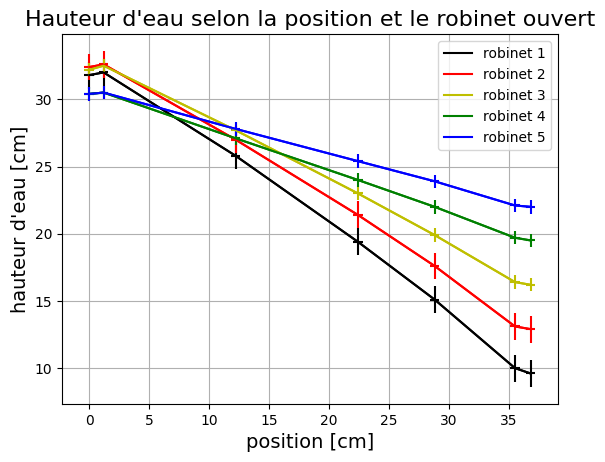

In [30]:
def graphe():
    colors = ['k','r','y','g','b']
    fig,ax = plt.subplots()
    ax.grid()
    ax.set_title(f"Hauteur d'eau selon la position et le robinet ouvert",fontsize=16)
    for n in range (len(data_h)):
        h = data_h[n]
        herr = data_herr[n]
        #affichage
        ax.plot(x,h,color=colors[n],label = f'robinet {n+1}')
        ax.errorbar(x,h,color=colors[n],yerr=herr, xerr=xerr)
    ax.set_xlabel('position [cm]',fontsize=14)
    ax.set_ylabel("hauteur d'eau [cm]",fontsize=14)
    ax.legend()
    #plt.savefig(r'C:\Users\Nicolas Onillon\Documents\UNINe\géologie\hauteur_eau.pdf')

graphe()

In [20]:
def function_for_fit1(x,h2): #H=31.8
    return 31.8**2-h2*x
def function_for_fit2(x,h2): #H=32.4
    return 32.4**2-h2*x
def function_for_fit3(x,h2): #H=32.2
    return 32.2**2-h2*x
def function_for_fit4(x,h2): #H=30.4
    return 30.4**2-h2*x
def function_for_fit5(x,h2): #H=30.4
    return 30.4**2-h2*x
lst_fit_functions = [function_for_fit1, function_for_fit2, function_for_fit3, function_for_fit4, function_for_fit5]

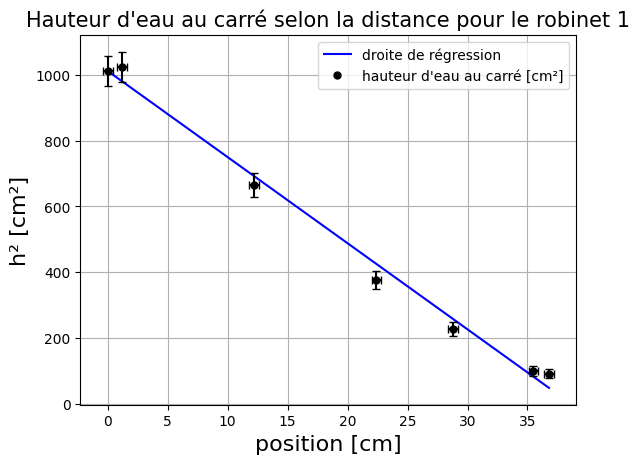

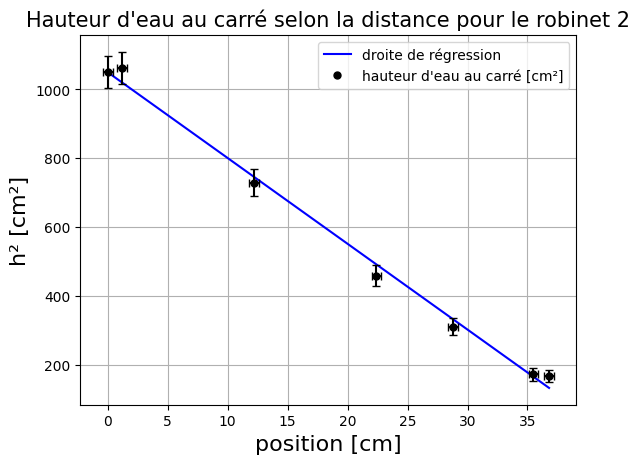

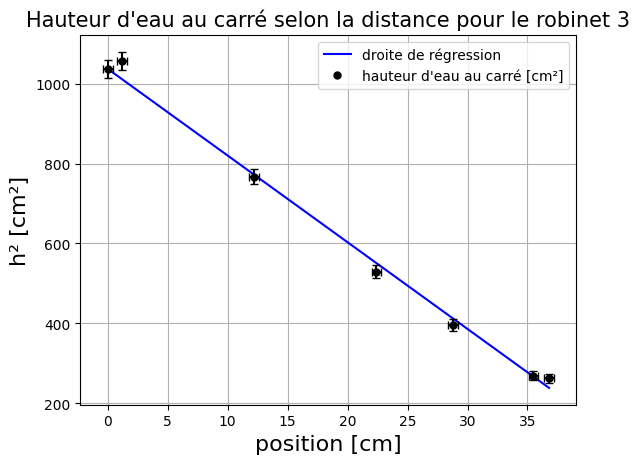

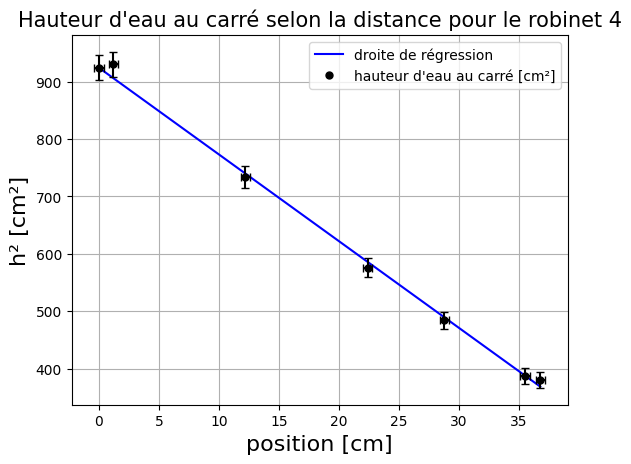

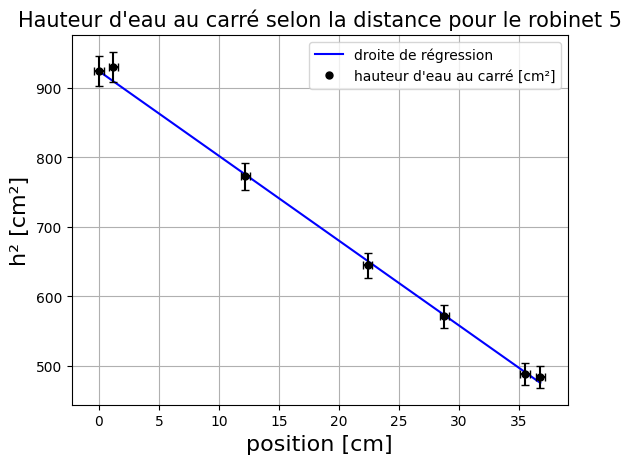

In [31]:
name = ['robinet_01','robinet_02','robinet_03','robinet_04','robinet_05']
def hauteur_carre(n):
    h = data_h[n]
    herr = data_herr[n]
    h2 = h**2
    h2err = h2*(2*(herr/h)**2)**(1/2)
    popt,pcov =curve_fit(lst_fit_functions[n],x,h2)
    pente = popt.squeeze()
    perr = np.sqrt(pcov).squeeze()
    #affichage
    fig,ax = plt.subplots()
    ax.plot(x,lst_fit_functions[n](pente,x),'b', label='droite de régression')
    ax.plot(x,h2,'k',marker='o', linestyle='none',linewidth=0,markersize=5, label = "hauteur d'eau au carré [cm\u00B2]")
    ax.errorbar(x,h2,yerr=h2err,xerr=xerr,c='k',linestyle='none',capsize=3)
    ax.set_xlabel('position [cm]',fontsize=16)
    ax.set_ylabel('h\u00B2 [cm\u00B2]',fontsize=16)
    ax.grid()
    ax.set_title(f"Hauteur d'eau au carré selon la distance pour le robinet {n+1}", fontsize=15)
    plt.legend()
    #plt.savefig(f'C:/Users/Nicolas Onillon/Documents/UNINe/géologie/{name[n]}.pdf')

for k in range(5):
    hauteur_carre(k)

In [26]:
#calcul K et permeabilite intrinseque k
lst_K = []
lst_Kerr = []
lst_k = []
lst_kerr = []

def calcul():
    for n in range(5):
        print (f"Robinet {n+1}:")
        pos = x
        #hauteur
        h = data_h[n]
        herr = data_herr[n]
        h2 = h**2
        h2err = h2*(2*(herr/h)**2)**(1/2)
        #debit
        Q = data_Q[n]
        Qerr = data_Qerr[n]
        #pente
        popt,pcov =curve_fit(lst_fit_functions[n],pos,h2)
        pente = popt.squeeze()
        perr = np.sqrt(pcov).squeeze()
        #conductivite
        K = 2*Q/(l*pente)
        Kerr = K*((lerr/l)**2+(perr/pente)**2+(Qerr/Q)**2)**(1/2)
        #afficher K
        print(f"K: {K} cm/s +/- {Kerr}")
        #permeabilite intrinseque
        mu = data_mu[n]
        muerr = data_muerr[n]
        rho = data_rho[n]
        rhoerr = data_rerr[n]
        k = K/100*mu/(rho*g)
        kerr = k*((Kerr/K)**2+(muerr/mu)**2+(rhoerr/rho)**2)**(1/2)
        print (f"k: {k} m\u00B2 +/- {kerr} \n ------")
        #ajouter aux listes
        lst_K.append(K)
        lst_Kerr.append(Kerr)
        lst_k.append(k)
        lst_kerr.append(kerr)

Robinet 1:
K: 0.06513397607401954 cm/s +/- 0.0021802461923542613
k: 6.652854748643007e-11 m² +/- 1.349094337171894e-11 
 ------
Robinet 2:
K: 0.05624035529958376 cm/s +/- 0.001889190600118881
k: 6.88644060569239e-11 m² +/- 1.7370953561123473e-11 
 ------
Robinet 3:
K: 0.057948603744763794 cm/s +/- 0.0020341862240721383
k: 7.686910648486705e-11 m² +/- 1.7943245227983027e-11 
 ------
Robinet 4:
K: 0.058487288269369095 cm/s +/- 0.002453417566031766
k: 7.758367414323582e-11 m² +/- 1.8197475985765785e-11 
 ------
Robinet 5:
K: 0.05107773424247393 cm/s +/- 0.002838791805727128
k: 6.775486446203196e-11 m² +/- 1.6082946900782034e-11 
 ------


In [27]:
def moyenne_ponderee(x,sigma):
    w = []
    for i in range(len(sigma)):
        w.append(1/sigma[i]**2)

    # Calcul des xiwi
    wx = []
    for i in range(len(x)):
        wx.append(x[i]*w[i])

    # Calcul de la moyenne ponderee
    mean = sum(wx)/sum(w)

    # Calcul de l'ecart à la moyenne de xi
    ecart_moy = []
    for i in range(len(x)):
        ecart_moy.append(w[i]*(x[i]-mean)**2)

    # Calcul sigma
    sigma_x = np.sqrt(sum(ecart_moy)/sum(w))

    return mean, 2*sigma_x


In [29]:
# Calcul de alpha moyen et de son erreur
calcul()
mean_K, sigma_K = moyenne_ponderee(lst_K, lst_Kerr)
print(f'K = {mean_K} +/- {sigma_K} cm/s')

# Calcul de c0 moyen et de son erreur

mean_k, sigma_k = moyenne_ponderee(lst_k, lst_kerr)
print(f'k = {mean_k} +/- {sigma_k} m\u00B2')

Robinet 1:
K: 0.06513397607401954 cm/s +/- 0.0021802461923542613
k: 6.652854748643007e-11 m² +/- 1.349094337171894e-11 
 ------
Robinet 2:
K: 0.05624035529958376 cm/s +/- 0.001889190600118881
k: 6.88644060569239e-11 m² +/- 1.7370953561123473e-11 
 ------
Robinet 3:
K: 0.057948603744763794 cm/s +/- 0.0020341862240721383
k: 7.686910648486705e-11 m² +/- 1.7943245227983027e-11 
 ------
Robinet 4:
K: 0.058487288269369095 cm/s +/- 0.002453417566031766
k: 7.758367414323582e-11 m² +/- 1.8197475985765785e-11 
 ------
Robinet 5:
K: 0.05107773424247393 cm/s +/- 0.002838791805727128
k: 6.775486446203196e-11 m² +/- 1.6082946900782034e-11 
 ------
K = 0.058212548233651115 +/- 0.008277578433023075 cm/s
k = 7.067658446003518e-11 +/- 9.243659205009908e-12 m²
